In [1]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [28]:
from functools import partial

from IPython.display import display, Markdown, Image
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, HoltWinters
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase

In [3]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


### 8.1 Simple Exponential Smoothing (SES)
**Explanation:** This method calculates forecasts using weighted averages of past observations, where the weights decay exponentially as you go further back in time. This means the model assumes recent observations are far more relevant than older ones, but it doesn't completely ignore the past. 
*   **Forecast equation: $$\hat{y}_{T+1|T} = \ell_{t}$$**
*   **Formula (Weighted Average Form):** $$ \ell_{t} = \alpha y_t + (1-\alpha) \ell_{t-1} $$
*   **Use Case:** **Forecasting stable data with no clear trend or repeating seasonal pattern**. For example, predicting the next period's export volume of a commodity that fluctuates randomly around a relatively stable level, like the total exports from a country over several years.

The application of every exponential smoothing method requires the smoothing parameters and the initial values to be chosen. In particular, for simple exponential smoothing, we need to select the values of $\alpha$ and $l$. All forecasts can be computed from the data once we know those values. So, you need to optimize these parameters by using the SSE (Sum of Squared errors).

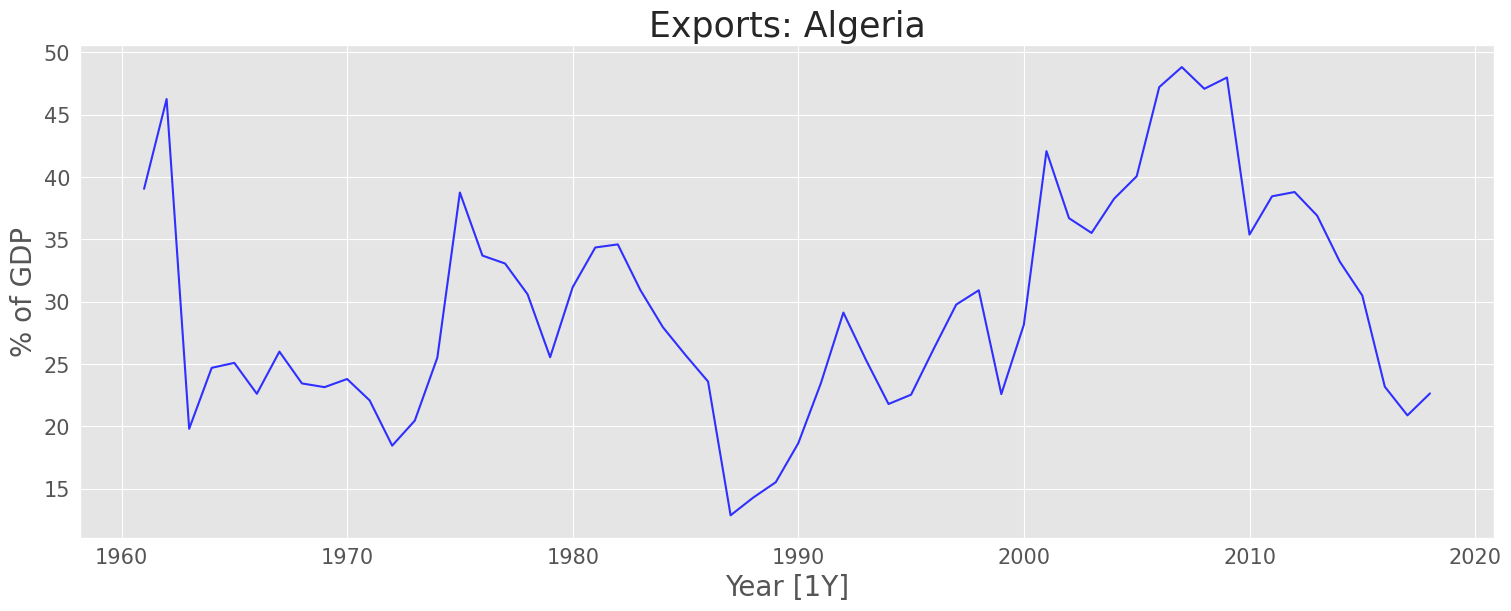

In [6]:
algeria_economy = pd.read_csv(DATA_DIR / "algeria_exports.csv",
    parse_dates=["ds"])
plt.rcParams["figure.figsize"] = (8, 4.3)
plot_series(algeria_economy,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Exports: Algeria")

In [9]:
model = AutoETS(model= "ANN", alias = "SES")
sf = StatsForecast(models=[model], freq="Y")
forecasts = sf.forecast(df=algeria_economy,h=10, level=[80, 95], fitted = True)
# Setting fitted=True will save the fitted values
# so that they can be accessed later through the forecast_fitted_values

forecasts.head()

,unique_id,ds,SES,SES-lo-95,SES-lo-80,SES-hi-80,SES-hi-95
0,Algeria,2018-12-31,22.442,10.523,14.648,30.235,34.361
1,Algeria,2019-12-31,22.442,6.875,12.263,32.620,38.009
2,Algeria,2020-12-31,22.442,3.933,10.339,34.544,40.951
3,Algeria,2021-12-31,22.442,1.398,8.682,36.202,43.486
4,Algeria,2022-12-31,22.442,-0.863,7.204,37.680,45.746


In [10]:
fitted_vals = sf.forecast_fitted_values()
fitted_vals.head()

,unique_id,ds,y,SES,SES-lo-95,SES-lo-80,SES-hi-80,SES-hi-95
0,Algeria,1960-12-31,39.043,39.530,27.720,31.808,47.252,51.340
1,Algeria,1961-12-31,46.245,39.121,27.311,31.399,46.843,50.931
2,Algeria,1962-12-31,19.794,45.105,33.295,37.383,52.828,56.916
3,Algeria,1963-12-31,24.685,23.842,12.031,16.119,31.564,35.652
4,Algeria,1964-12-31,25.084,24.550,12.740,16.828,32.272,36.360


The `forecast()` method of the `StatsForecast` class is optimised for speed and scalability, so it does not store the estimated model parameters. Those can be accessed after using the `.fit()` or `.fit_predict()` method:

In [11]:
# Save model fit(s)
sf.fit(algeria_economy)
# Save model fit(s) and return forecasts
fc = sf.fit_predict(df=algeria_economy, h=5, level=[80, 95])
params = sf.fitted_[0, 0].model_["fit"].x
alpha, level_0 = np.round(params, 4)

In [12]:
ses = AutoETS(model="ANN", alias="SES")
ses.fit(y=algeria_economy["y"].values)
params = ses.model_["fit"].x
alpha, level_0 = np.round(params, 4)
print("Optimal parameters:")
print("alpha:", alpha)
print("Initial level:", level_0)

Optimal parameters:
alpha: 0.8401
Initial level: 39.53


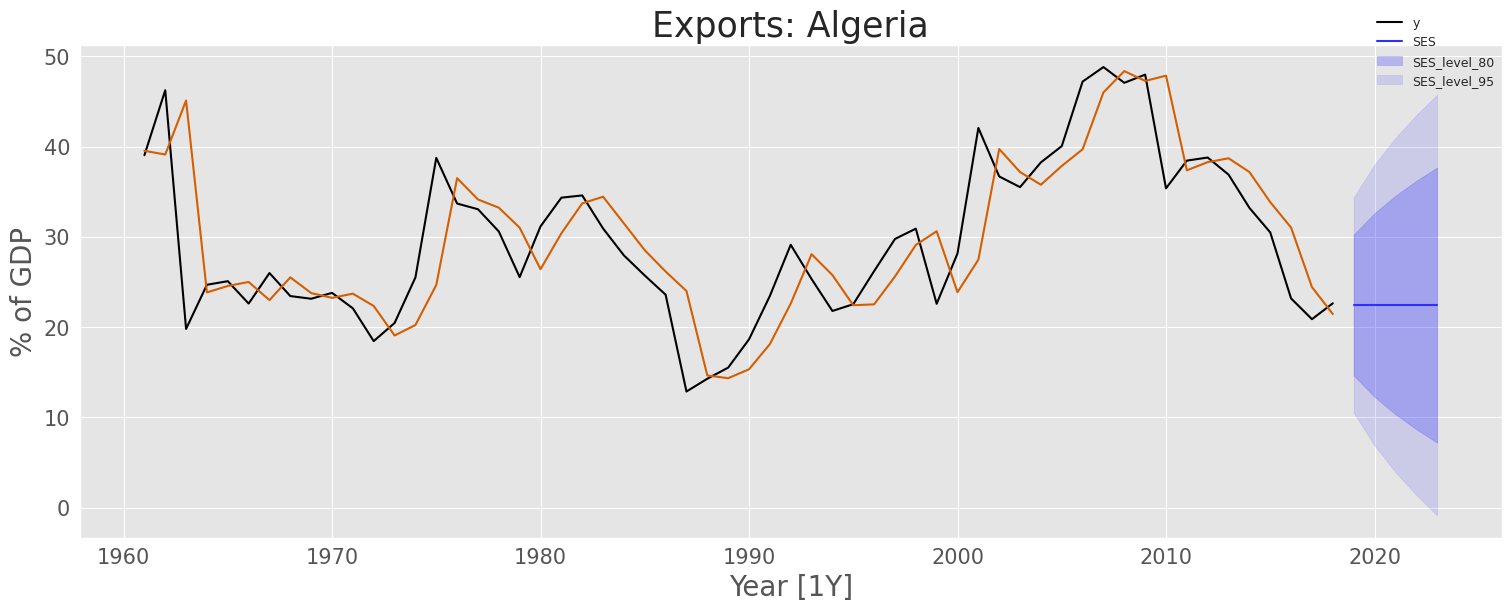

In [14]:
fig = plot_series(algeria_economy, fc, level=[80, 95],
    xlabel="Year [1Y]", ylabel="% of GDP", title="Exports: Algeria",
    palette="black_and_blue", rm_legend=False)
fig.axes[0].plot("ds", "SES", data=fitted_vals, color="#D55E00")
fig

The prediction intervals show that there is considerable uncertainty in the future exports over the five-year forecast period. So interpreting the point forecasts without accounting for the large uncertainty can be misleading.

### 8.2 Methods with Trend
**Explanation:** This extends SES to capture data that is generally moving upwards or downwards. 
*   **Use Case:** **Data with a clear trajectory but no seasonality.** You would use Holt's Linear method for something with persistent linear growth, like tracking an annual population increase. You would use the **Damped Trend method** for something like internet server usage or a new product's rapid growth phase, where you realistically expect the growth rate to eventually slow down and plateau.

*   **Holt's Linear Trend:** Assumes the current trend (slope) will continue indefinitely at the exact same rate.
    *   **Forecast equation:** $$ \hat{y}_{t+h|t} = \ell_{t} + hb_{t} $$
    *   **Level equation:** $$ \ell_{t} = \alpha y_t + (1-\alpha) (\ell_{t-1} + b_{t-1}) $$
    *   **Trend equation:** $$ b_t = \beta^*(\ell_{t} - \ell_{t-1}) + (1-\beta^*)b_{t-1}$$
    * where 
        * $\ell_{t} denotes an estimate of the level of the series at time t$
        * $b_t$ denotes an estimate of the trend (slope) of the series at time t
        * $\alpha ~(0 \le \alpha \le 1)$ is the smoothing parameter for the level
        * $\beta^* ~(0 \le \beta^* \le 1)$ is the smoothing parameter for the trend.

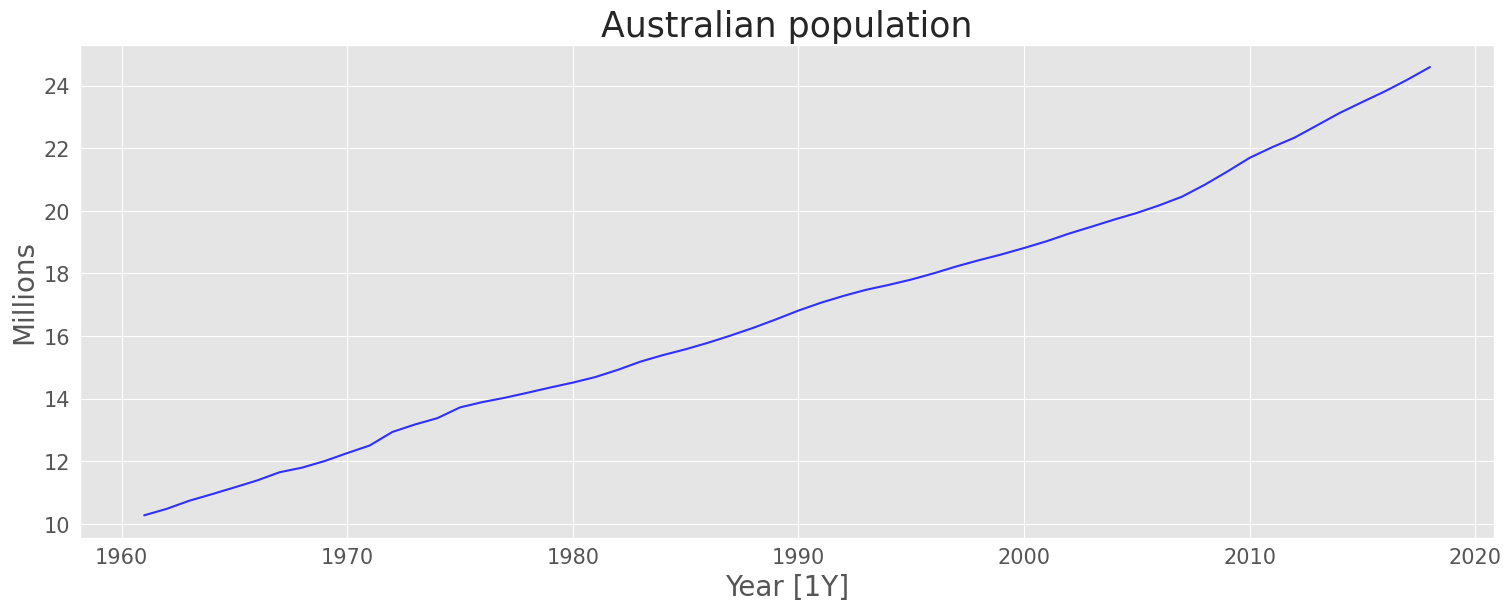

In [15]:
aus_economy = (
    pd.read_csv(DATA_DIR / "aus_economy.csv", parse_dates=["ds"])
    .assign(y=lambda x: x["y"] / 1e6)
)
plot_series(aus_economy, xlabel="Year [1Y]", ylabel="Millions",
    title="Australian population")

In [16]:
sf = StatsForecast(models=[AutoETS(model="AAN", alias="Holt")], freq="A")
fc = sf.fit_predict(df=aus_economy, h=10)

In [17]:
holt = sf.fitted_[0, 0]
params = np.round(holt.model_["fit"].x, 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("beta:", params[1])
print("Initial level:", params[2])
print("Initial trend:", params[3])

Optimal parameters:
alpha: 0.9999
beta: 0.2001
Initial level: 10.0509
Initial trend: 0.2264


*   **Damped Trend:** Empirical evidence shows that assuming a trend will continue forever often leads to over-forecasting. The damped method introduces a parameter ($\phi$) that "flattens" the trend into a horizontal line over time, making long-term predictions much safer.
    *   **Forecast equation:** $$ \hat{y}_{t+h|t} = \ell_{t} + (\phi + \phi^2 + ... + \phi^h)b_{t} $$
    *   **Level equation:** $$ \ell_{t} = \alpha y_t + (1-\alpha) (\ell_{t-1} + \phi b_{t-1}) $$
    *   **Trend equation:** $$ b_t = \beta^*(\ell_{t} - \ell_{t-1}) + (1-\beta^*)\phi b_{t-1}$$
    * If $\phi = 1$, the method is identical to Holt’s linear method. For values between 0 and 1, $\phi$ dampens the trend so that it approaches a constant some time in the future. This means that short-run forecasts are trended while long-run forecasts are constant.
    * In practice, $\phi$ is rarely less than 0.8 as the damping has a very strong effect for smaller values. Values of $\phi$ close to 1 will mean that a damped model is not able to be distinguished from a non-damped model. For these reasons, we usually restrict $\phi$ to a minimum of 0.8 and a maximum of 0.98.

In [18]:
sf = StatsForecast(
  models=[
    AutoETS(model="AAN", alias="Holt"),
    AutoETS(model="AAN", alias="Damped Holt's method",
      damped=True, phi=0.9),
  ],
  freq="Y",
)
fc = sf.forecast(df=aus_economy, h=15)

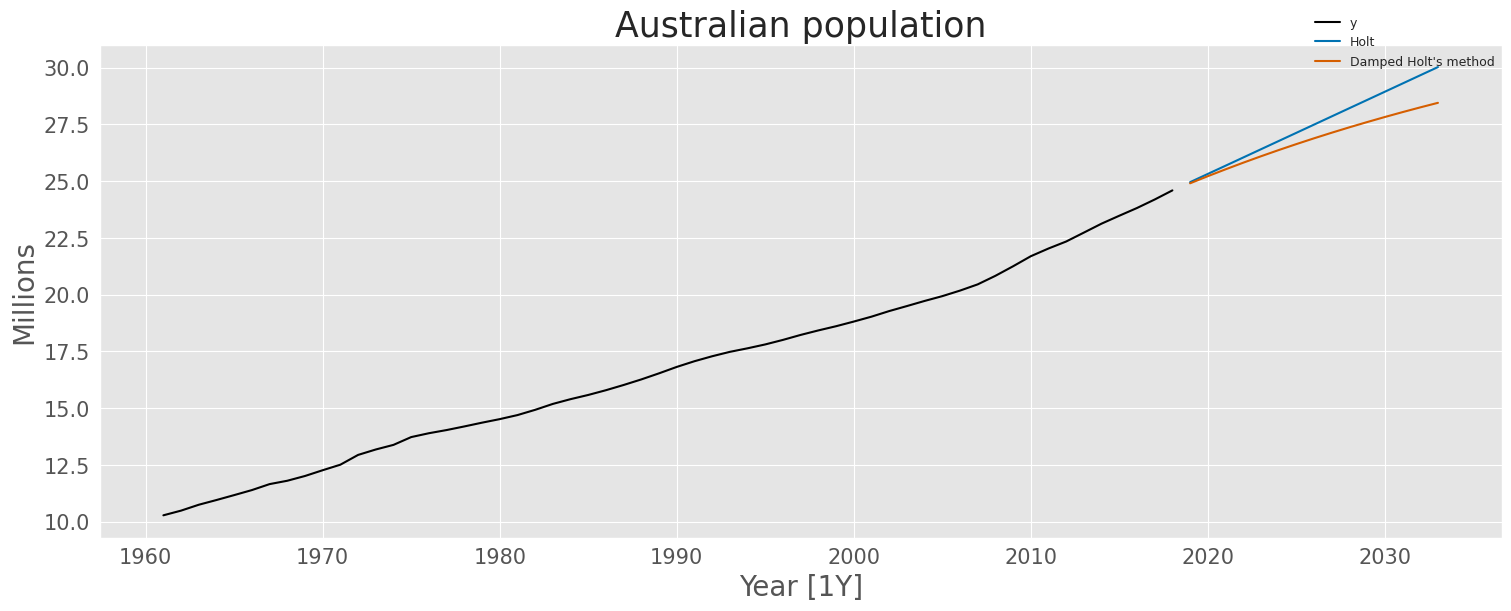

In [20]:
plot_series(aus_economy, fc,
  xlabel="Year [1Y]", ylabel="Millions", title="Australian population",
  palette="black_and_2color", rm_legend=False,)

Example: Internet usage

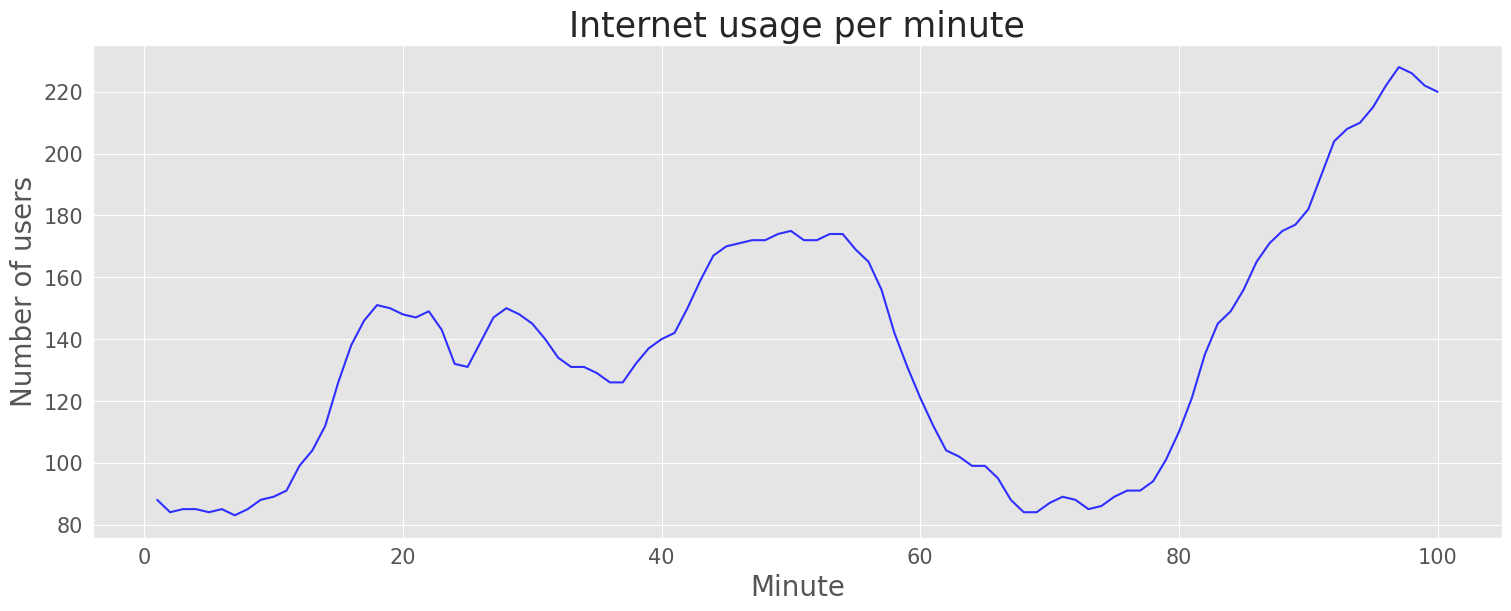

In [21]:
www_usage = pd.read_csv(DATA_DIR / "www_usage.csv")
plot_series(www_usage, xlabel="Minute", ylabel="Number of users",
  title="Internet usage per minute")

In [22]:
from utilsforecast.losses import mape as _mape
def mape(df, models, id_col = "unique_id", target_col = "y"):
    """MAPE scaled to percentage."""
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

sf = StatsForecast(
    models=[
        AutoETS(model="ANN", alias="SES"),
        AutoETS(model="AAN", alias="Holt"),
        AutoETS(model="AAN", damped=True, phi=0.9, alias="Damped"),
    ],
    freq=1,
)
cv = sf.cross_validation(df=www_usage, h=1, n_windows=90, step_size=1)
result_df = evaluate(
    cv.drop("cutoff", axis=1),
    metrics=[rmse, mae, mape, partial(mase, seasonality=1)],
    train_df=www_usage,
)
(result_df.drop(columns="unique_id")
    .set_index("metric").T
    .rename(columns=str.upper))

metric,RMSE,MAE,MAPE,MASE
SES,6.072,4.849,3.588,1.072
Holt,5.086,4.181,3.164,0.924
Damped,5.037,4.057,3.058,0.896


In [23]:
sf = StatsForecast(
    models=[AutoETS(model="AAN", damped=True, alias="Damped")],
    freq=1,
)
sf.fit(www_usage)
params = np.round(sf.fitted_[0, 0].model_["fit"].x, 4)
print("Optimal parameters:")
print("Damped alpha:", params[0])
print("Damped beta:", params[1])
print("Damped phi:", params[2])
print("Initial level:", params[3])
print("Initial trend:", params[4])

Optimal parameters:
Damped alpha: 0.9999
Damped beta: 0.2
Damped phi: 0.9087
Initial level: 88.8688
Initial trend: -0.9231


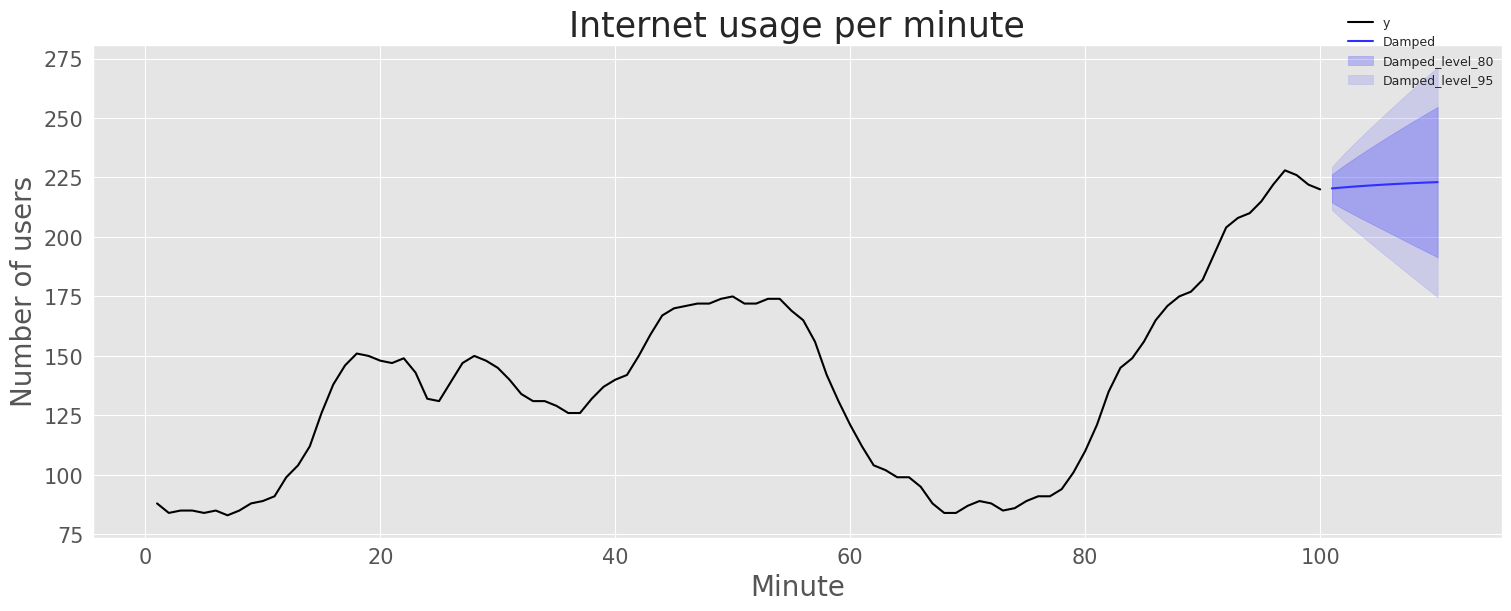

In [24]:
level = [80, 95]
fc = sf.predict(h=10, level=level)
plot_series(www_usage, fc, level=level,
    xlabel="Minute", ylabel="Number of users",
    title="Internet usage per minute",
    palette="black_and_blue", rm_legend=False,)

### 8.3 Methods with Seasonality (Holt-Winters)
**Explanation:** This method adds a third component to handle data with repeating seasonal cycles (e.g., monthly or quarterly patterns). You must choose between two variations based on the shape of your data:
*   **Additive Seasonality:** Use this when the seasonal peaks and valleys are roughly the same size year after year, regardless of the overall level of the data. 
*   **Multiplicative Seasonality:** Use this when the seasonal variations grow or shrink proportionally as the overall level of the series changes (e.g., the spikes get much taller as sales increase).
    *   **Formula (Additive Forecast):** $$ \hat{y}_{t+h|t} = \ell_{t} + hb_{t} + s_{t+h-m(k+1)} $$
    *   **Level equation:** $$ \ell_{t} = \alpha (y_t-s_{t-m}) + (1-\alpha) (\ell_{t-1} + b_{t-1}) $$
    *   **Trend equation:** $$ b_t = \beta^*(\ell_{t} - \ell_{t-1}) + (1-\beta^*)b_{t-1}$$
    *   **Seasonal equation:** $$ s_t = \gamma (y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)s_{t-m}$$
    * where 
        * $k$ is the integer paprt of $(h-1)/m$, which ensures that the estimates of the seasonal indices used for forecasting come from the final year of the sample.
        * The level equation shows a weighted average between the seasonally adjusted observation $(y_t - s_{t-m})$ and the non-seasonal forecast $(\ell_{t-1} + b_{t-1})$
        * $b_t$ denotes an estimate of the trend (slope) of the series at time t
        * $\alpha ~(0 \le \alpha \le 1)$ is the smoothing parameter for the level
        * $\beta^* ~(0 \le \beta^* \le 1)$ is the smoothing parameter for the trend.
        * With $\gamma = \gamma^*(1-\alpha)$. The usual parameter retriction is $0 \le \gamma^* \le 1$, which translates to $0 \le \gamma \le 1-\alpha$

    * Additionally, There is Holt-Winters’ damped method that is possible with both additive and multiplicative Holt-Winters’ methods. We need add $\phi$ at front of $b_{t-1} in above formulas.$

    
    *  **Formula (Multiplicative Forecast):** $$ \hat{y}_{t+h|t} = (\ell_{t} + hb_{t})s_{t+h-m(k+1)} $$
    *   **Level equation:** $$ \ell_{t} = \alpha \frac{y_t}{s_{t-m}} + (1-\alpha) (\ell_{t-1} + b_{t-1}) $$
    *   **Trend equation:** $$ b_t = \beta^*(\ell_{t} - \ell_{t-1}) + (1-\beta^*)b_{t-1}$$
    *   **Seasonal equation:** $$ s_t = \gamma \frac{y_t}{(\ell_{t-1} - b_{t-1})} + (1-\gamma)s_{t-m}$$
*   **Use Case:** **Data driven by calendar events or seasons.** You would use the Additive method for daily pedestrian traffic at a train station (where the rush hour volume remains relatively constant). You would use the Multiplicative method for forecasting summer tourist nights, where a booming year means the summer peak grows significantly larger in absolute terms.


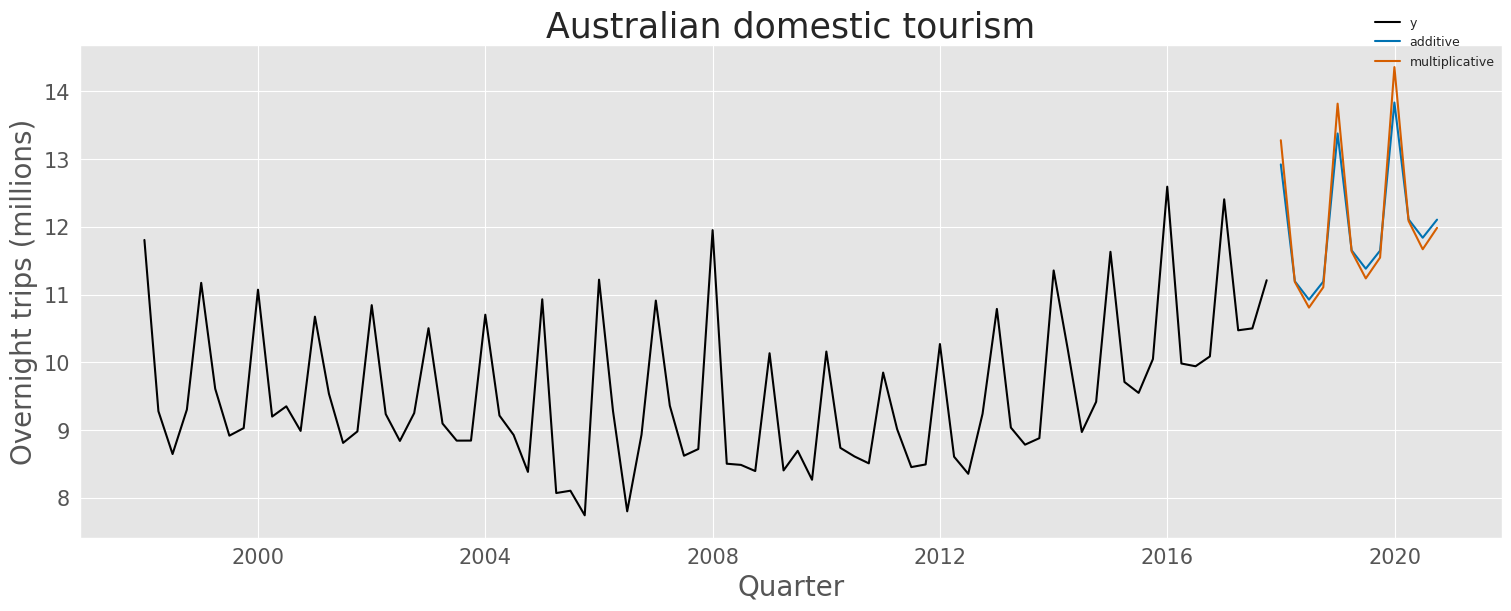

In [26]:
tourism = pd.read_csv(DATA_DIR / "tourism.csv", parse_dates=["ds"])
aus_holidays = (
    tourism.loc[lambda x: x["Purpose"] == "Holiday"]
    .rename(columns={"Purpose": "unique_id"})
    .groupby(["unique_id", "ds"])
    ["y"].sum().div(1e3)
    .reset_index()
)
sf = StatsForecast(
    models=[
        AutoETS(season_length=4, model="AAA", alias="additive"),
        AutoETS(season_length=4, model="MAM", alias="multiplicative"),
    ],
    freq="Q",
)
fc = sf.forecast(df=aus_holidays, h=12, fitted=True)
plot_series(aus_holidays, fc,
    xlabel="Quarter", ylabel="Overnight trips (millions)",
    title="Australian domestic tourism",
    palette="black_and_2color", rm_legend=False,)

In [29]:
HoltWinters(season_length=4, error_type="A", alias="additive")
HoltWinters(season_length=4, error_type="M", alias="multiplicative")

multiplicative

In [30]:
fitted_vals = sf.forecast_fitted_values()
evaluate(fitted_vals, metrics=[rmse])

,unique_id,metric,additive,multiplicative
0,Holiday,rmse,0.412,0.412


In [31]:
sf.fit(aus_holidays)
for model in sf.fitted_[0]:
    print(model)
    # parameters: [alpha, beta, gamma, phi, l0, (b0 if trend), s1, ..., sm]
    par = model.model_["par"]
    components = model.model_["components"]
    trendtype = components[1]
    alpha, beta, gamma = np.round(par[:3], 4)
    level_0 = np.round(par[4], 4)
    seasonal_start = 4 + 1 + (1 if trendtype != "N" else 0)
    seasonal = np.round(par[seasonal_start:], 4)
    print("  Optimal parameters:")
    print("  alpha:", alpha)
    print("  beta:", beta)
    print("  gamma:", gamma)
    print("  Initial level:", level_0)
    print("  Initial seasonal components:", seasonal)
    print("  Sum of seasonal components:", seasonal.sum())

additive
  Optimal parameters:
  alpha: 0.2325
  beta: 0.03
  gamma: 0.0001
  Initial level: 9.8372
  Initial seasonal components: [-0.5386 -0.6916 -0.3051  1.5353]
  Sum of seasonal components: 2.220446049250313e-16
multiplicative
  Optimal parameters:
  alpha: 0.239
  beta: 0.0274
  gamma: 0.0008
  Initial level: 9.8161
  Initial seasonal components: [0.9429 0.9265 0.9688 1.1618]
  Sum of seasonal components: 4.0


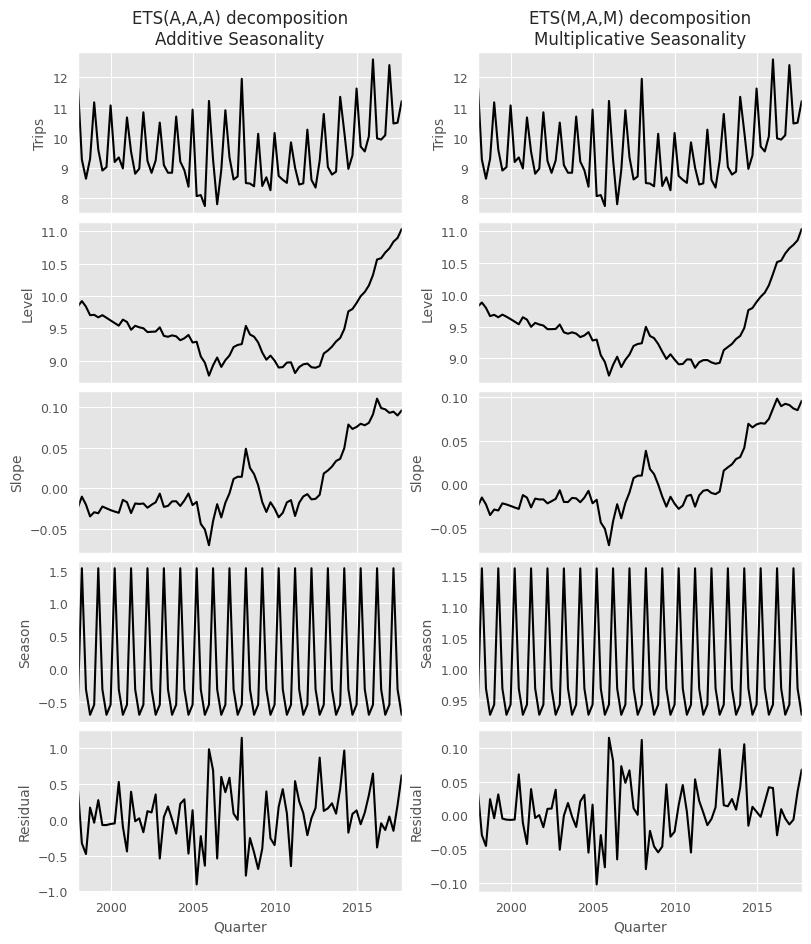

In [32]:
titles = [
    "ETS(A,A,A) decomposition\nAdditive Seasonality",
    "ETS(M,A,M) decomposition\nMultiplicative Seasonality",
]
states = ["Level", "Slope", "Season"]

fig, all_axes = plt.subplots(5, 2, figsize=(8, 8*14/12), sharex=True)
for (axes, title, model) in zip(all_axes.T, titles, sf.fitted_[0]):
    states = model.model_["states"]
    df = pd.DataFrame({
        "Trips": aus_holidays["y"].to_numpy(),
        "Level": states[:, 0][:-1],
        "Slope": states[:, 1][:-1],
        "Season": states[:, 2][:-1],
        "Residual": model.model_["residuals"],
        "Quarter": aus_holidays["ds"].to_numpy(),
    }).set_index("Quarter")
    for (ax, column) in zip(axes, df.columns):
        df[column].plot(ax=ax, ylabel=column)
    axes[0].set(title=title)


### 8.4 A Taxonomy of Exponential Smoothing Methods
**Explanation:** This provides a simple structural framework for matching your specific time series to one of nine possible methods. By looking at your data, you categorize its Trend (None, Additive, or Additive Damped) and its Seasonality (None, Additive, Multiplicative). 

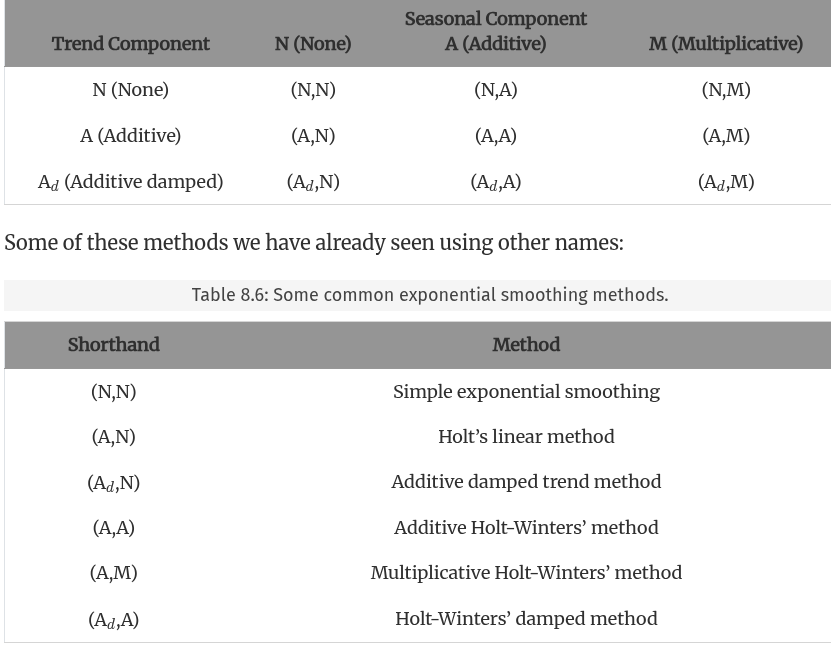

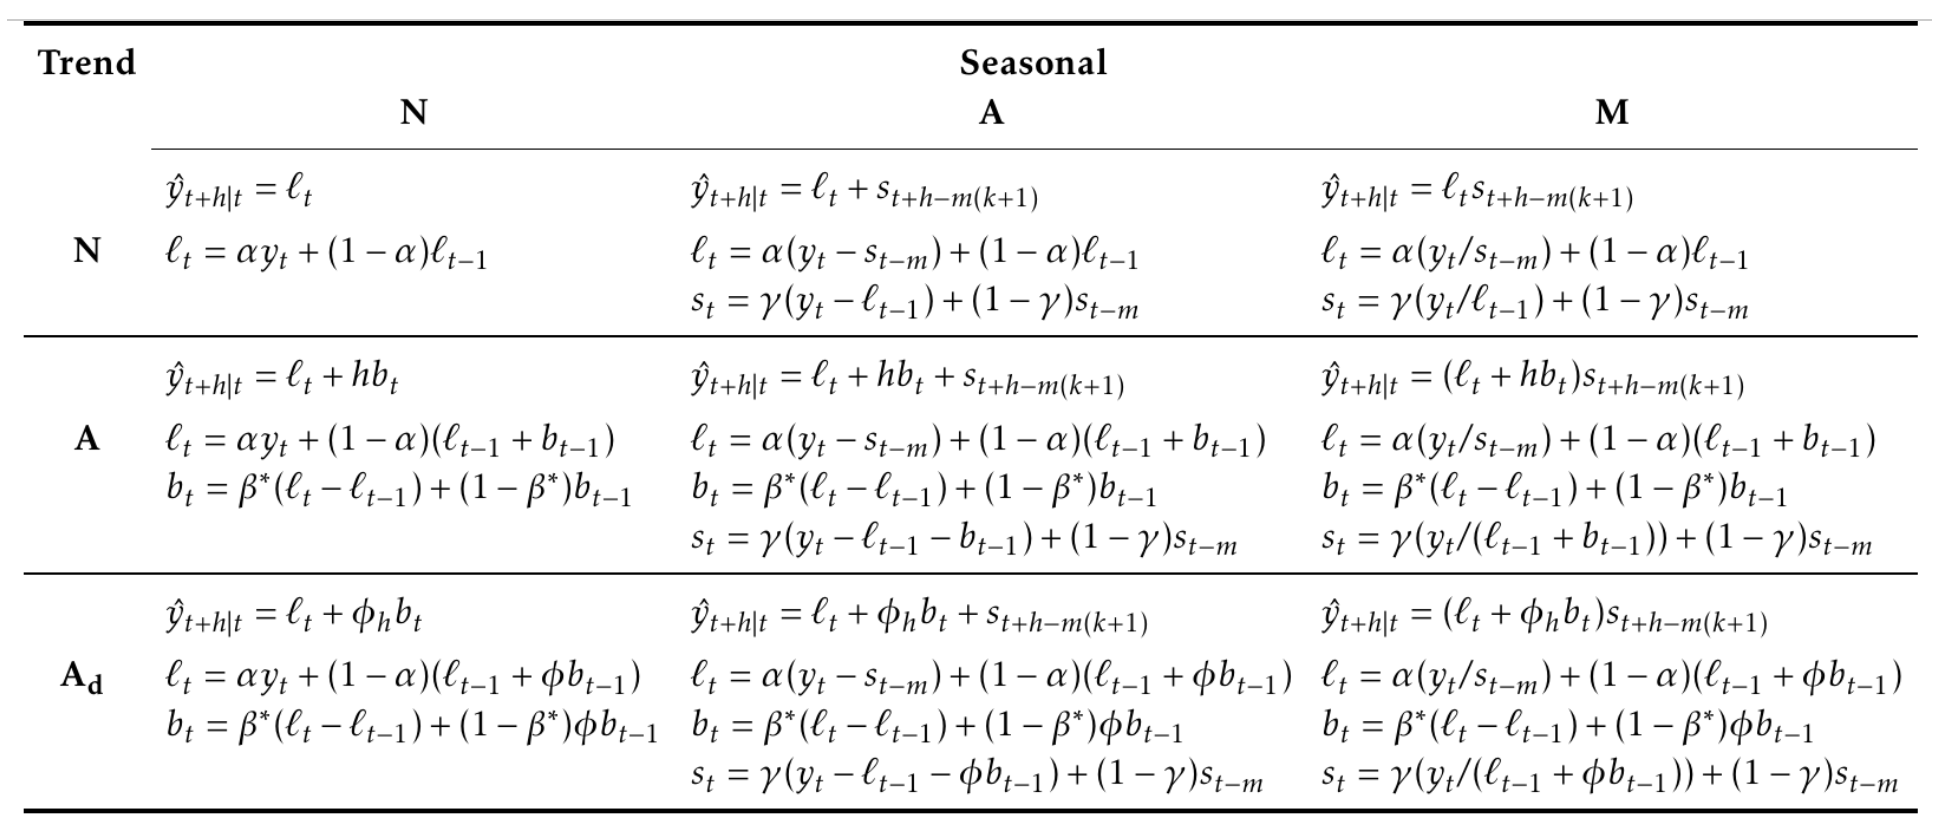

*   **Use Case:** **A visual checklist for model building.** If you plot your data and visually identify a leveling-off trend along with percentage-based seasonal spikes, you can immediately cross-reference the taxonomy to select a method with a Damped Trend and Multiplicative Seasonality $(A_d, M)$.


### 8.5 Innovations state space models for exponential smoothing (ETS)

Section 8.5 transitions from viewing exponential smoothing merely as algorithmic methods (which only generate point forecasts) to fully specified statistical models known as **innovations state space models**. These models generate the exact same point forecasts but also provide a framework for computing probability distributions, generating prediction intervals, and objectively selecting the best model.

These are called "state space models" because they consist of two types of equations:
1.  **Measurement (or observation) equation:** Describes how the observed data relates to unobserved states (level, trend, seasonal) and the unpredictable error.
2.  **State (or transition) equations:** Describes how these unobserved components change over time.

They are labelled **ETS (Error, Trend, Seasonal)**, where the possibilities for each component are: Error = {A, M}, Trend = {N, A, $A_d$} and Seasonal = {N, A, M}.

#### 1. ETS(A,N,N): Simple exponential smoothing with additive errors
Assuming the one-step training errors ($\varepsilon_t$) are normally and independently distributed as white noise with mean 0 and variance $\sigma^2$ (denoted as $\varepsilon_t \sim \text{NID}(0,\sigma^2)$):
*   **Measurement equation:** $y_t = \ell_{t-1} + \varepsilon_t$
*   **State equation:** $\ell_t = \ell_{t-1} + \alpha \varepsilon_t$

#### 2. ETS(M,N,N): Simple exponential smoothing with multiplicative errors
If the errors are strictly relative (percentages), the model is written as:
*   **Measurement equation:** $y_t = \ell_{t-1}(1 + \varepsilon_t)$
*   **State equation:** $\ell_t = \ell_{t-1}(1 + \alpha \varepsilon_t)$

#### 3. ETS(A,A,N): Holt’s linear method with additive errors
By setting $\beta = \alpha \beta^*$, the state space model for Holt's linear method is:
*   **Measurement equation:** $y_t = \ell_{t-1} + b_{t-1} + \varepsilon_t$
*   **State (Level):** $\ell_t = \ell_{t-1} + b_{t-1} + \alpha \varepsilon_t$
*   **State (Trend):** $b_t = b_{t-1} + \beta \varepsilon_t$

#### 4. ETS(M,A,N): Holt’s linear method with multiplicative errors
Using relative errors, the multiplicative error version of Holt's method is:
*   **Measurement equation:** $y_t = (\ell_{t-1} + b_{t-1})(1 + \varepsilon_t)$
*   **State (Level):** $\ell_t = (\ell_{t-1} + b_{t-1})(1 + \alpha \varepsilon_t)$
*   **State (Trend):** $b_t = b_{t-1} + \beta(\ell_{t-1} + b_{t-1})\varepsilon_t$

**Explanation & Use Case:** The ETS framework turns an algorithm into a true data-generating model. While earlier sections taught you how to calculate an average, this section allows you to treat the prediction errors as a core part of the mathematical process. This is highly useful when your business stakeholder asks, *"What is the worst-case scenario?"* Because you now have a statistical distribution of the errors, you can provide mathematical boundaries for your forecasts.

***

### 8.6 Estimation and model selection

Section 8.6 explains how to objectively find the unknown parameters (like $\alpha$, $\beta$, $\gamma$) and the initial states (like $\ell_0$, $b_0$, $s_0$) using the data, rather than manually guessing them.

#### Estimating ETS models
The parameters are estimated by **maximising the likelihood** (the probability that the observed data arose from the specified model). For models with additive errors, this yields the exact same results as minimising the Sum of Squared Errors (SSE). 

To ensure the models work properly and older data doesn't disproportionately affect current forecasts, the smoothing parameters are constrained:
*   $0 < \alpha < 1$
*   $0 < \beta < \alpha$
*   $0 < \gamma < 1 - \alpha$
*   $0.8 < \phi < 0.98$ (damping parameter restriction to avoid numerical issues)

#### Model Selection using Information Criteria
Because ETS methods are fully specified statistical models, we can use Information Criteria to automatically and objectively select the best model (e.g., deciding whether to use an additive or multiplicative trend). The formulas balance the model's accuracy against its complexity:
*   **Akaike's Information Criterion (AIC):**
    $$ \text{AIC} = -2\log(L) + 2k $$
*   **Corrected AIC (AICc) - Recommended:**
    $$ \text{AIC}_c = \text{AIC} + \frac{2k(k+1)}{T-k-1} $$
*   **Bayesian Information Criterion (BIC):**
    $$ \text{BIC} = \text{AIC} + k[\log(T)-2] $$
*(Where $L$ is the likelihood, $k$ is the number of parameters/initial states, and $T$ is the number of observations).*

**Important Exclusions:**
Models with multiplicative errors are unstable if the data contains zeros or negative numbers, so they should only be used on strictly positive data. Furthermore, ETS(A,N,M), ETS(A,A,M), and ETS(A,$A_d$,M) can cause numerical instability (due to potential division by zero in the state equations) and are generally avoided.

**Explanation & Use Case:** This is the most practical feature of modern forecasting libraries. Instead of subjectively choosing between the 30+ combinations of Exponential Smoothing models, you can compute the AICc for all stable models and simply **select the model with the lowest AICc score**. This enables rapid, automated forecasting across thousands of products (e.g., retail inventory systems).

***

### 8.7 Forecasting with ETS models

Section 8.7 details how the estimated ETS models actually project into the future. 

#### Generating Point Forecasts
To generate point forecasts, the model equations are iteratively calculated for the required forecast horizon $t = T+1, \dots, T+h$. For future time periods, **all future error terms ($\varepsilon_t$) are set to 0**.
For example, the 1-step and 2-step forecasts for the ETS(M,A,N) model are mathematically derived as:
*   $\hat{y}_{T+1|T} = \ell_T + b_T$
*   $\hat{y}_{T+2|T} = \ell_{T+1} + b_{T+1} = \ell_T + 2b_T$
These point forecasts are generally equal to the mean of the forecast distribution (except for models with multiplicative seasonality).

#### Generating Prediction Intervals
The key benefit of the ETS framework is calculating prediction intervals using the format:
$$ \hat{y}_{T+h|T} \pm c \sigma_h $$
*(Where $c$ is the multiplier for the desired coverage probability, such as $1.96$ for 95%, and $\sigma_h$ is the forecast standard deviation)*.

For models where the mathematical formula for the forecast variance ($\sigma_h^2$) is too complex or unknown, algorithms simply simulate thousands of possible future sample paths (bootstrapping) and calculate the percentiles to form the boundaries.

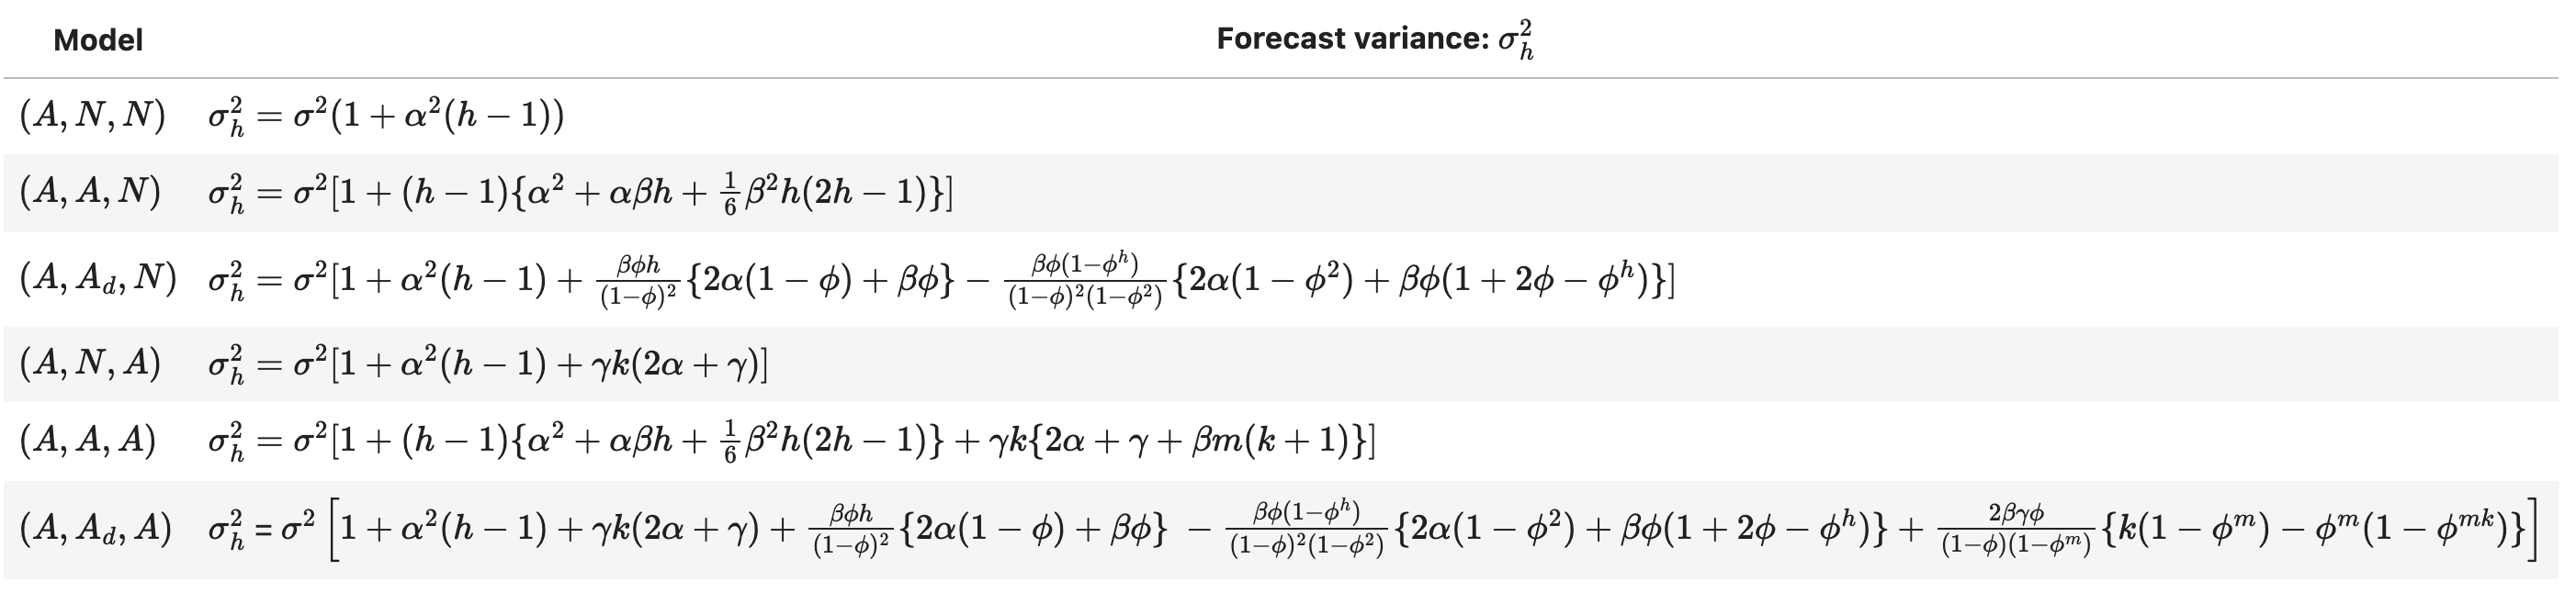

**Explanation & Use Case:** This allows you to communicate confidence alongside your predictions. For example, if you are forecasting daily server load, generating an 80% and 95% prediction interval using $\hat{y}_{T+h|T} \pm c \sigma_h$ tells the IT team exactly how much buffer capacity they need to provision to avoid a crash during unexpected spikes.